# Synthetic Data Augmentation with Conditional Flow Matching

## Overview

In this project, we employ conditional flow matching (CFM) with classifier-free guidance (CFG) to generate synthetic data for fashion item classification. By leveraging guided generative modeling, our approach achieves measurable improvements in classification accuracy and $\mathsf F_1$ score.

## Setup

In [1]:
!find . -mindepth 1 -exec rm -rf {} + &> /dev/null
!git clone https://github.com/ZhangLyndon/FlowMatchingAugmentation . &> /dev/null

In [2]:
!pip install -qU -r requirements.txt

In [3]:
import os
import argparse

# Reduce CUDA memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torchvision
import numpy as np

# Components for building, training, and simulating a conditional flow matching
# model
from flow import (EulerSimulator, FlowMatchingPipeline,
                  CFGVectorFieldODE, ConditionalVectorField,
                  FourierEncoder, ResidualLayer, Encoder, Midcoder, Decoder, UNet,
                  IsotropicGaussian, Sampler, GaussianConditionalProbabilityPath,
                  LinearAlpha, LinearBeta,
                  CFGTrainer)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["font.family"] = "DejaVu Sans Mono"

## Part 1

We begin by training a conditional flow matching model with classifier-free guidance on the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset, a standard benchmark for image classification. Class-conditional synthetic images are generated and used to augment the training of a ResNet-18 model. By integrating these synthetic images into the training process, we aim to demonstrate measurable improvements in classification accuracy and macro $\mathsf F_1$ score.

In [4]:
# Configure flow matching pipeline
flow_args = argparse.Namespace(num_samples = 6000, seed = 42, checkpoint_dir = "./checkpoints")

# Set random seed for reproducibility
torch.manual_seed(flow_args.seed)

# Initialize pipeline, generate samples, and apply postprocessing (removing
# ImageNet normalization before saving generated samples)
flow = FlowMatchingPipeline()
flow.generate_samples(samples_per_class = flow_args.num_samples)

# Save model checkpoint
flow.save_checkpoint(flow_args.checkpoint_dir)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


Model Size: 4.715 MiB


Epoch 5999, Loss: 172.08106994628906: 6000it [18:13,  5.49it/s]


Samples generated with guided conditional flow matching can be previewed below, at guidance scales $w \in \{3.0, 5.0\}$.

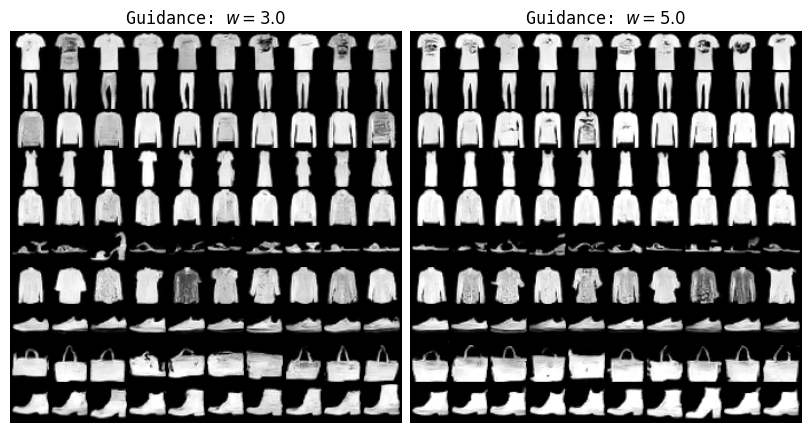

In [5]:
samples_per_class = 10
num_classes = 10
num_timesteps = 100
guidance_scales = [3.0, 5.0]

fig, axes = plt.subplots(1, len(guidance_scales), figsize = (4 * len(guidance_scales), 4.8), constrained_layout = True)
for idx, w in enumerate(guidance_scales):
    ode = CFGVectorFieldODE(flow.unet, guidance_scale = w)
    simulator = EulerSimulator(ode)

    y = torch.arange(10, dtype = torch.int64).repeat_interleave(samples_per_class).to(flow.device)
    num_samples = y.shape[0]
    x0, _ = flow.path.p_simple.sample(num_samples)

    ts = torch.linspace(0, 1, num_timesteps).view(1, -1, 1, 1, 1).expand(num_samples, -1, 1, 1, 1).to(flow.device)
    x1 = simulator.simulate(x0, ts, y = y)

    grid = torchvision.utils.make_grid(x1, nrow = samples_per_class, normalize = True, value_range = (-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap = "gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"Guidance: $w = {w:.1f}$")

We review the theoretical foundation and neural network architecture underpinning the image generation process. In conditional image generation, the objective is to synthesize images corresponding to a specific text prompt or _class label_ $y$. Let $x\in\mathbb R^{1\times 32\times 32}$ denote an image (i.e, a fashion product), and let $y\in\{0, 1, \dots, 9\}$ represent the conditioning label specifying the desired clothing category. The task is to learn a neural network $u_t^\theta(x\vert y)$ that approximates the vector field transporting samples $X_t$ from an initial noise $p_\mathrm{init}$ towards a conditional data distribution $p_\mathrm{data}(x\vert y)$.

To achieve this, we train a generative model according to the guided conditional flow matching objective
$$
\begin{align*}
\mathcal L^\mathrm{guided}_\mathrm{CFM}(\theta) & = \mathrm{E}_{\Box}\left[\left\lvert u_t^\theta(x\vert y) - u_t^\mathrm{target}(x\vert z)\right\rvert^2\right] \\
\Box & = (z, y) \sim p_\mathrm{data}(z, y), x\sim p_t(x\vert z), t\sim\mathcal U[0, 1).
\end{align*}
$$

We sample pairs $(z, y)\sim p_\mathrm{data}(z, y)$ by drawing an image $z$ and its corresponding label $y$ from the labeled dataset. Using a Gaussian conditional probability path $p_t(x\vert z) = \mathcal N(\alpha_tz, \beta_t^2I_d)$ to interpolate between noise and data, we obtain the _training target_
$$
\begin{align*}
u_t^\mathrm{target}(x\vert y) & = \left(\frac{\beta_t^2\dot\alpha_t - \alpha_t\dot\beta_t\beta_t}{\alpha_t}\right)\nabla\log p_t(x\vert y) + \frac{\dot\alpha_t}{\alpha_t}x \\
& = u_t^\mathrm{target}(x) + \left(\frac{\beta_t^2\dot\alpha_t - \alpha_t\dot\beta_t\beta_t}{\alpha_t}\right)\nabla\log p_t(y\vert x) \\
& = u_t^\mathrm{target}(x) + b_t\nabla\log p_t(y\vert x).
\end{align*}
$$
Under a linear schedule for $\alpha_t$ and linear decay for $\beta_t$, this reduces to $u_t^\mathrm{target}(x\vert y) = u_t^\mathrm{target}(x) + \left(\frac{1 - t}{t}\right)\nabla\log p_t(y\vert x)$.

The guided vector field $u_t^\mathrm{target}(x\vert y)$ can be written as the sum of an unguided vector field $u_t^\mathrm{target}(x)$, plus the gradient of the likelihood $\nabla\log p_t(y\vert x)$ of the guidance variable. The second term may be interpreted as a classifier $-$ i.e., given a noisy image, what is the label?

The strength of this classifier term may be tuned by scaling $\tilde{u}_t^\mathrm{target}(x\vert y) = u_t^\mathrm{target}(x) + wb_t\nabla\log p_t(y\vert x)$, where $w > 1$ is the _guidance scale_. Rearranging this expression yields the scaled guided vector field $\tilde{u}_t^\mathrm{target}(x\vert y) = (1 - w)u_t^\mathrm{target}(x) + wu_t^\mathrm{target}(x\vert y)$.

To avoid having to train separate unguided and guided vector fields, we note that the unguided vector field $u_t^\mathrm{target}(x)$ corresponds to the absence of conditioning. Therefore, we may augment our label set to include a null class $\varnothing$, such that
$$
\begin{align*}
u_t^\mathrm{target}(x) & = u_t^\mathrm{target}(x\vert\varnothing) \\
y & = \{0, 1, \dots, 9, \varnothing\},
\end{align*}
$$
to yield the classifier-free guided vector field
$$
\tilde{u}_t^\mathrm{target}(x\vert y) = (1 - w)u_t^\mathrm{target}(x\vert\varnothing) + wu_t^\mathrm{target}(x\vert y).
$$

We never obtain $y = \varnothing$ directly when sampling image $z$/label $y$ pairs from the dataset, so this possibility must be introduced artificially. We define the hyperparameter $\eta$ to be the _probability_ that we discard the original label $y$ and replace it with $\varnothing$. The conditional flow matching objective for classifier-free guidance therefore follows
$$
\begin{align*}
\mathcal L^\mathrm{CFG}_\mathrm{CFM}(\theta) & = \mathrm{E}_{\Box}\left[\left\lvert u_t^\theta(x\vert y) - u_t^\mathrm{target}(x\vert z)\right\rvert^2\right] \\
\Box & = (z, y) \sim p_\mathrm{data}(z, y), x\sim p_t(x\vert z), t\sim\mathcal U[0, 1), \text{replace $y = \varnothing$ with probability $\eta$}.
\end{align*}
$$

To represent the null label $\varnothing$, we assign it to an index (e.g., $\varnothing = 10$), and map this index to an embedding, or higher-dimensional numerical representation. The training procedure is therefore as follows:

1. Sample an image $z$ and label $y$ from $p_\mathrm{data}$.
2. With probability $\eta$, replace the label $y$ with the null label $\varnothing\overset{\Delta}{=} 10$.
3. Sample a time step $t$ from $\mathcal U[0, 1]$.
4. Sample an interpolated image $x$ from the conditional probability path $p_t(x\vert z)$.
5. Regress $u_t^\theta(x\vert y)$ against $u_t^\mathrm{target}(x\vert z)$.

The U-Net architecture, a type of convolutional neural network, is used to learn the guided velocity field $u_t^\theta(x\vert y)$. It is composed of the following components:

1. To embed time $t\in[0, 1)$, we use learnable Fourier features with frequency weights $w$, to capture high-frequency time dependence. The time embedding is given by
$$
\begin{align*}
\operatorname{TimeEmb}(t) = \sqrt{2}
\begin{bmatrix}
\sin\left(2\pi w_1t\right) & \cos\left(2\pi w_1t\right) & \dots & \sin(2\pi w_{d/2}t) & \cos(2\pi w_{d/2}t)
\end{bmatrix},
\end{align*}
$$
where the normalization factor $\sqrt{2}$ factor scales individual components to roughly have unit variance.

2. To embed class labels, we learn a separate embedding vector for each of the $N + 1$ classes (including the null label), and set $y$ to this vector.

3. Time and class embeddings are converted into channel-specific modulations that apply to every spatial location (pixel), via an affine transformation.

4. The core building block is the residual layer, which takes an input image $x_t\in\mathbb R^{C_\mathrm{in}\times H\times W}$ and computes the cross-correlation between the input patch and corresponding kernel weight, i.e.,
$$
\begin{align*}
\mathrm{output}\big(C_\mathrm{out}, i, j\big) = \sum_{C_\mathrm{in}}\big[\mathrm{input}\big(C_\mathrm{in}\big)\star\mathrm{weight}\big(C_\mathrm{out}, C_\mathrm{in}\big)\big]\big(i, j\big) + \mathrm{bias}\big(C_\mathrm{out}\big)
\end{align*}
$$
to obtain spatial features at each pixel location by performing a weighted aggregation of its local neighborhood.

5. As convolution layers aggregate information over neighboring pixels, high-frequency details such as edges are blurred. Furthermore, in deep (multi-layer) neural networks, the gradients of the loss with respect to early-layer parameters $\theta_n$ are frequently _vanishing_, such that repeated derivatives of each layer's outputs with respect to its inputs cause error signals to decay exponentially as they backpropagate to earlier layers.

    Short range residual connections, applied after the convolutional blocks within each residual layer, help stabilize gradients, while long-range residual connections connect each encoder/decoder pair and help preserve fine spatial detail.

6. The U-Net itself is built out of 2 encoder/decoder pairs, with a latent processing block in between known as the midcoder.

    a) Encoders consist of a sequence of residual layers that extracts features from, and embeds conditioning information within, image feature maps with the specified number of input channels. A subsequent downsampling convolution halves the spatial resolution while doubling the channel count, enabling the network to capture increasingly abstract representations.

    b) The midcoder consists of a series of residual layers that processes feature maps at the lowest spatial resolution and highest channel count to capture global context.

    c) Decoders mirror the encoder structure but in reverse. Each decoder stage begins with an upsampling step, performing bilinear interpolation to increase the spatial resolution, followed by a convolution that halves the number of channels. Subsequent residual layers incorporate time step and class conditioning, to progressively refine and reconstruct the image output at higher resolutions.

7. Images take the following path through the neural network:

    a) An initial convolution transforms 1-channel grayscale inputs into feature maps at the starting channel count, while preserving spatial resolution.

    b) A sequence of encoders progressively downsamples the feature map while doubling the channel count to extract increasingly abstract features. The output feature map is cloned to add back later as a residual connection.

    c) The midcoder processes features at the most abstract representation (here, at 128 channels and 8 by 8 resolution).

    d) Residual connections add encoder feature maps back to corresponding decoder stages in LIFO order to preserve fine-grained spatial detail. Each decoder then upsamples the feature map via bilinear interpolation, followed by a convolution that halves the channel count, to reconstruct the image output.

    e) A final convolution produces a 1-channel prediction for the conditional vector field from decoded features.